In [2]:
import numpy as np
import matplotlib.pyplot as plt
from operator import itemgetter

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim

import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint, EarlyStopping

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [4]:
from torch.utils.data import TensorDataset, DataLoader, random_split, SubsetRandomSampler

In [193]:
import matplotlib.pylab as pylab
import warnings
import matplotlib.cbook

from plot_params import params

warnings.filterwarnings("ignore",category=matplotlib.cbook.mplDeprecation)

pylab.rcParams.update(params)
cols_default = plt.rcParams['axes.prop_cycle'].by_key()['color']

In [5]:
device = 'cuda'

In [6]:
# import os

# # Assumes wget is available! Otherwise, use curl or download manually
# # from https://dspace.mit.edu/handle/1721.1/105492
# os.system("wget https://dspace.mit.edu/bitstream/handle/1721.1/105492/fermi_data.tar.gz?sequence=5");
# os.system("tar -xvf fermi_data.tar.gz?sequence=5");
# os.system("rm -r fermi_data.tar.gz*");

In [7]:
import skimage

In [8]:
n_pixels = 64

In [ ]:
from functools import partial

import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

# Build a map
nside = 64
npix = hp.nside2npix(nside)
hpxmap = np.arange(npix)

# Get the cutout via a cartesian projection
lonra = [30, 40]
latra = [-10, 10]

proj = hp.projector.CartesianProj(
    lonra=lonra, latra=latra,
    coord='G',
    xsize=n_pixels, ysize=n_pixels)
reproj_im = proj.projmap(hpxmap, vec2pix_func=partial(hp.vec2pix, nside))

# Plot the cutout
plt.imshow(reproj_im, origin='lower', interpolation='nearest')


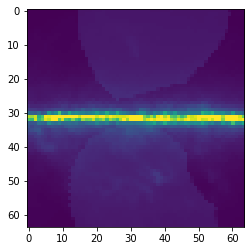

In [40]:
import healpy as hp
from functools import partial

nside= 128
lonra = [-30, 30]
latra = [-30, 30]

dif_hp = np.load("fermi_data/template_dif.npy")
bub_hp = np.load("fermi_data/template_bub.npy")

proj = hp.projector.CartesianProj(lonra=lonra, latra=latra,
    coord='G',
    xsize=n_pixels, ysize=n_pixels)

dif_cart = proj.projmap(dif_hp, vec2pix_func=partial(hp.vec2pix, nside))
bub_cart = proj.projmap(bub_hp, vec2pix_func=partial(hp.vec2pix, nside))

plt.imshow(7 * dif_cart + 3 * bub_cart, vmax=100)

In [162]:
from scipy.stats import binned_statistic_2d
from astropy.convolution import convolve, Gaussian2DKernel
from scipy.stats import norm

t_min = -1  # Coordinate boundaries
t_max = 1
n_t = n_pixels  # Number of pixels
counts_min = 150  # Minimum and maximum counts emitted by each PS
counts_max = 250
fwhm_psf = 0.1  # FWHM of Gaussian PSF

# Pixel binning
pixel_size = (t_max - t_min) / n_t
bins = np.linspace(t_min, t_max, n_t + 1)

# PSF stuff
sigma_psf = fwhm_psf / 2 ** 1.5 * np.sqrt(np.log(2))  # Convert FWHM to standard deviation
kernel = Gaussian2DKernel(x_stddev=1.0 * sigma_psf / pixel_size)

def simulate(plot=False, poiss_fluctuate=True):
    
    mu_iso = np.random.uniform(1, 20)
    mu_ps_iso = np.random.uniform(5, 150)
    
    n_ps_iso = np.random.poisson(mu_ps_iso)
    
    # Draw position of PSs and their counts
    z_x_iso = np.random.uniform(t_min, t_max, size=(2, n_ps_iso))
    z_c_iso = np.random.uniform(counts_min, counts_max, n_ps_iso)
    
    mu_ps_csp = np.random.uniform(0, 10)
    n_ps_csp = 0  # np.random.poisson(mu_ps_csp)
    
    # Draw position of PSs and their counts
    z_x_csp = norm.rvs(loc=0, scale=0.5, size=(2, n_ps_csp)) 
    z_c_csp = np.random.uniform(counts_min, counts_max, n_ps_csp)
    
    mu_iso_map = mu_iso * np.ones((n_t, n_t))

    if n_ps_iso > 0:
        mu_signal_iso = binned_statistic_2d(x=z_x_iso[0], y=z_x_iso[1], values=z_c_iso, statistic='sum', bins=bins).statistic
    else:
        mu_signal_iso = np.zeros_like(mu_iso_map)
        
    if n_ps_csp > 0:
        mu_signal_csp = binned_statistic_2d(x=z_x_csp[0], y=z_x_csp[1], values=z_c_csp, statistic='sum', bins=bins).statistic
    else:
        mu_signal_csp =  np.zeros_like(mu_iso_map)
        
    counts_binned = (mu_iso_map + 4 * dif_cart + 4 * bub_cart + convolve(mu_signal_iso, kernel) + convolve(mu_signal_csp, kernel))

    if poiss_fluctuate:
        counts_binned = np.random.poisson(counts_binned)

    if plot:
        plt.imshow(counts_binned)
    
    return counts_binned, mu_iso, mu_ps_iso

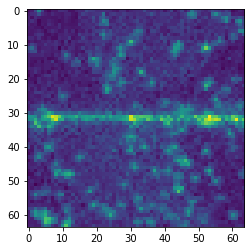

In [163]:
_, _, _ = simulate(plot=True)

In [164]:
from tqdm.notebook import tqdm
simulations = [simulate() for _ in tqdm(range(30000))]

  0%|          | 0/30000 [00:00<?, ?it/s]

## Glow (generative flow on images)

In [165]:
import sys
sys.path.append("../")
sys.path.append("../.")

from models.glow import Glow

In [166]:
model = Glow(num_channels=256, num_levels=3, num_steps=16)

In [167]:
from operator import itemgetter

x = list(map(itemgetter(0), simulations))
x = torch.Tensor(x)
x = x.unsqueeze(1)

mu_iso = list(map(itemgetter(1), simulations))
mu_ps_iso = list(map(itemgetter(2), simulations))
y = torch.Tensor(np.array([mu_iso, mu_ps_iso])).T

### Reversibility test

In [168]:
x[:3]

tensor([[[[13., 20., 18.,  ..., 19., 16., 18.],
          [15., 18., 15.,  ..., 11., 16., 11.],
          [14., 14., 26.,  ..., 15., 10., 21.],
          ...,
          [19., 11., 20.,  ..., 18., 14., 22.],
          [13., 13., 15.,  ..., 37.,  9., 14.],
          [10., 15., 15.,  ..., 42., 22., 19.]]],


        [[[ 4.,  1.,  0.,  ...,  4., 19., 42.],
          [ 2.,  4.,  1.,  ...,  6., 12., 24.],
          [ 4., 14.,  3.,  ...,  4.,  3., 10.],
          ...,
          [ 2.,  3.,  2.,  ...,  1.,  4.,  3.],
          [ 5.,  3.,  4.,  ...,  3.,  3.,  3.],
          [ 1.,  3.,  3.,  ...,  2.,  5.,  2.]]],


        [[[42., 25.,  9.,  ...,  5., 13., 12.],
          [60., 35., 18.,  ..., 16.,  5., 16.],
          [28., 27., 18.,  ..., 13., 11., 18.],
          ...,
          [ 4., 13., 12.,  ..., 11., 12., 12.],
          [14., 14.,  7.,  ..., 18., 13., 10.],
          [14., 12., 11.,  ..., 14., 12., 16.]]]])

In [170]:
z, sldj = model(x[:3])

In [171]:
x_recon, sldj = model(z, reverse=True)

In [172]:
x_recon

tensor([[[[13, 20, 18,  ..., 19, 16, 18],
          [15, 18, 15,  ..., 11, 16, 11],
          [14, 14, 26,  ..., 15, 10, 21],
          ...,
          [19, 11, 20,  ..., 18, 14, 22],
          [13, 13, 15,  ..., 37,  9, 14],
          [10, 15, 15,  ..., 42, 22, 19]]],


        [[[ 4,  1,  0,  ...,  4, 19, 42],
          [ 2,  4,  1,  ...,  6, 12, 24],
          [ 4, 14,  3,  ...,  4,  3, 10],
          ...,
          [ 2,  3,  2,  ...,  1,  4,  3],
          [ 5,  3,  4,  ...,  3,  3,  3],
          [ 1,  3,  3,  ...,  2,  5,  2]]],


        [[[42, 25,  9,  ...,  5, 13, 12],
          [60, 35, 18,  ..., 16,  5, 16],
          [28, 27, 18,  ..., 13, 11, 18],
          ...,
          [ 4, 13, 12,  ..., 11, 12, 12],
          [14, 14,  7,  ..., 18, 13, 10],
          [14, 12, 11,  ..., 14, 12, 16]]]], dtype=torch.int32)

In [174]:
class NLLLoss(nn.Module):
    """Negative log-likelihood loss assuming isotropic gaussian with unit norm.
    Args:
        k (int or float): Number of discrete values in each input dimension.
            E.g., `k` is 256 for natural images.
    See Also:
        Equation (3) in the RealNVP paper: https://arxiv.org/abs/1605.08803
    """
    def __init__(self, k=256):
        super(NLLLoss, self).__init__()
        self.k = k

    def forward(self, z, sldj):
        prior_ll = -0.5 * (z ** 2 + np.log(2 * np.pi))
        prior_ll = prior_ll.flatten(1).sum(-1) \
            - np.log(self.k) * np.prod(z.size()[1:])
        ll = prior_ll + sldj
        nll = -ll.mean()

        return nll

In [175]:
loss = NLLLoss()

In [176]:
z, sldj = model(x[:3])

nll = loss(z, sldj)

nll

tensor(37069.7969, grad_fn=<NegBackward0>)

In [177]:
def bits_per_dim(x, nll):
    """Get the bits per dimension implied by using model with `loss`
    for compressing `x`, assuming each entry can take on `k` discrete values.
    Args:
        x (torch.Tensor): Input to the model. Just used for dimensions.
        nll (torch.Tensor): Scalar negative log-likelihood loss tensor.
    Returns:
        bpd (torch.Tensor): Bits per dimension implied if compressing `x`.
    """
    dim = np.prod(x.size()[1:])
    bpd = nll / (np.log(2) * dim)

    return bpd


In [178]:
bits_per_dim(x[:3], nll)

tensor(13.0567, grad_fn=<DivBackward0>)

### Flow training

In [179]:
class GlowPL(pl.LightningModule):

    def __init__(self):
        """
        Inputs:
            flows - A list of flows (each a nn.Module) that should be applied on the images.
        """
        super().__init__()
        self.flow = Glow(256, 3, 16)
        self.loss = NLLLoss()

    def log_prob(self, x):
        """
        Given a batch of images, return the likelihood of those.
        If return_ll is True, this function returns the log likelihood of the input.
        Otherwise, the ouptut metric is bits per dimension (scaled negative log likelihood)
        """
        
        z, sldj = self.flow(x)
        nll = self.loss(z, sldj)
        bpd = bits_per_dim(x, nll)
        
        return bpd

    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=3e-4, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5)
        
        return {"optimizer": optimizer, 
                    "lr_scheduler": {
                    "scheduler": scheduler,
                    "interval": "epoch",
                    "monitor": "val_loss",
                    "frequency": 1}
                }
    def training_step(self, batch, batch_idx):
        # Normalizing flows are trained by maximum likelihood => return bpd
        loss = self.log_prob(batch[0])
        self.log('train_loss', loss)
        return loss

    def validation_step(self, batch, batch_idx):
        loss = self.log_prob(batch[0])
        self.log('val_loss', loss)

In [180]:
val_fraction = 0.15
n_samples_val = int(val_fraction * len(x))

dataset = TensorDataset(x, y)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=100, num_workers=8, pin_memory=True, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=100, num_workers=8, pin_memory=True, shuffle=False)

In [181]:
model = GlowPL()

In [183]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss")
early_stop_callback = EarlyStopping(monitor='val_loss', patience=8)        
lr_monitor = LearningRateMonitor(logging_interval='epoch')

trainer = pl.Trainer(max_epochs=20, gpus=1, gradient_clip_val=1., callbacks=[checkpoint_callback, early_stop_callback, lr_monitor])
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)
model.load_from_checkpoint(checkpoint_callback.best_model_path);

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Set SLURM handle signals.

  | Name | Type    | Params
---------------------------------
0 | flow | Glow    | 4.8 M 
1 | loss | NLLLoss | 0     
---------------------------------
4.8 M     Trainable params
0         Non-trainable params
4.8 M     Total params
19.002    Total estimated model params size (MB)


Validation sanity check: 0it [00:00, ?it/s]

Training: -1it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

In [184]:
cmap = 'RdBu_r'

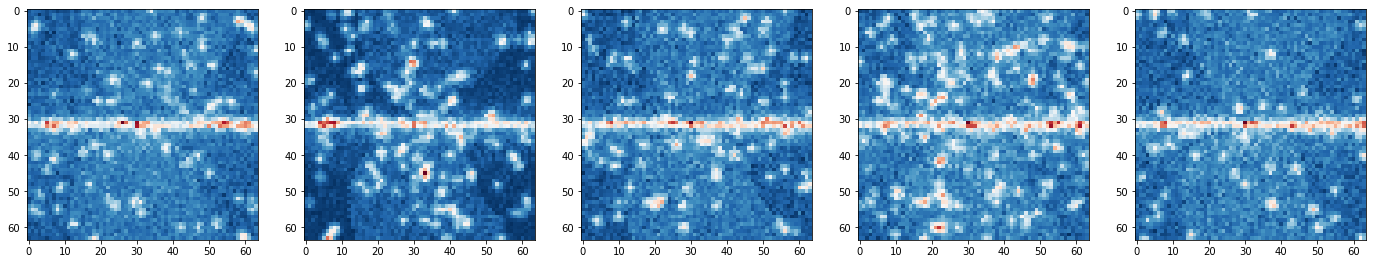

In [185]:
fig, axs = plt.subplots(1, 5, figsize=(16 * 1.5, 4 * 1.5))

for i, ax in enumerate(axs):
    ax.imshow(x[i,0].detach().numpy(), cmap=cmap)

In [186]:
z = torch.randn(size=(5, 1, 64,64))
x_samples, sldj = model.flow(z, reverse=True)

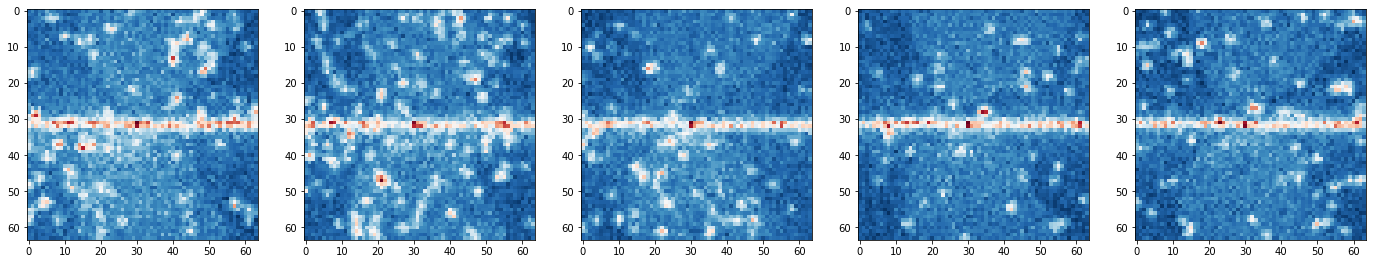

In [187]:
fig, axs = plt.subplots(1, 5, figsize=(16 * 1.5, 4 * 1.5))

for i, ax in enumerate(axs):
    ax.imshow(x_samples[i,0].detach().numpy(), cmap=cmap)

In [188]:
x_samples = torch.zeros(500, 1, 64, 64)
for i in tqdm(range(500)):
    z = torch.randn(size=(1, 1, 64,64))
    x_samples[i, :] = model.flow(z, reverse=True)[0][0]

  0%|          | 0/500 [00:00<?, ?it/s]

In [189]:
from scipy import stats

def power_spectrum(x):
    """ Power spectrum of map. Adapted from https://bertvandenbroucke.netlify.app/2019/05/24/computing-a-power-spectrum-in-python/
    """
    
    npix = x.shape[0]

    fourier_image = np.fft.fftn(x)
    fourier_amplitudes = np.abs(fourier_image)**2

    kfreq = np.fft.fftfreq(npix) * npix
    kfreq2D = np.meshgrid(kfreq, kfreq)
    knrm = np.sqrt(kfreq2D[0]**2 + kfreq2D[1]**2)

    knrm = knrm.flatten()
    fourier_amplitudes = fourier_amplitudes.flatten()

    kbins = np.arange(0.5, npix//2+1, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    Abins, _, _ = stats.binned_statistic(knrm, fourier_amplitudes,
                                         statistic = "mean",
                                         bins = kbins)
    Abins *= np.pi * (kbins[1:]**2 - kbins[:-1]**2)
    
    return Abins

def counts_histogram(x, counts_max=128):
    bins_hist = np.arange(counts_max)
    return np.histogram(x, bins=bins_hist)[0]

In [190]:
x_pspec_samples = np.array([power_spectrum(x_i) for x_i in x_samples[:, 0, :, :]])
x_pspec_train = np.array([power_spectrum(x_i) for x_i in x[:500, 0]])

x_hist_samples = np.array([counts_histogram(x_i) for x_i in x_samples])
x_hist_train = np.array([counts_histogram(x_i) for x_i in x[:500, 0]])

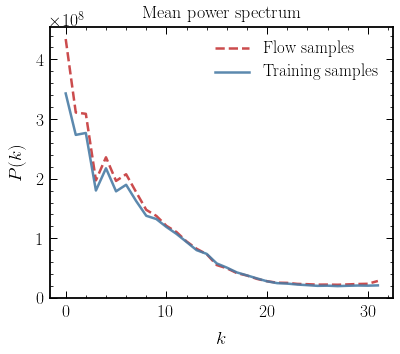

In [194]:
plt.plot(np.nanmean(x_pspec_samples, axis=0), label="Flow samples", ls='--')
plt.plot(np.mean(x_pspec_train, axis=0), label="Training samples")

plt.xlabel("$k$")
plt.ylabel("$P(k)$")
plt.title("Mean power spectrum")
         
plt.legend()

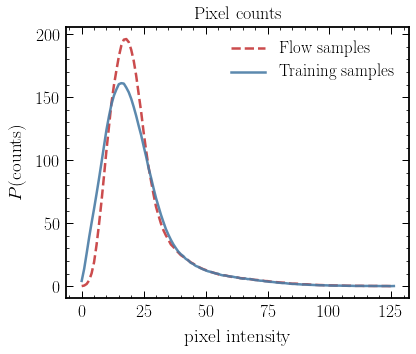

In [195]:
plt.plot(np.nanmean(x_hist_samples, axis=0), label="Flow samples", ls='--')
plt.plot(np.mean(x_hist_train, axis=0), label="Training samples")

plt.xlabel("pixel intensity")
plt.ylabel("$P(\mathrm{counts})$")
plt.title("Pixel counts")
         
plt.legend()

### Interpolating in latent space

In [199]:
def z_interp(z1, z2, weight=0.5):
    z_interp = torch.lerp(z1, z2, weight)
    return z_interp

In [200]:
z, _ = model.flow(x[:2])

In [216]:
vrange = 150

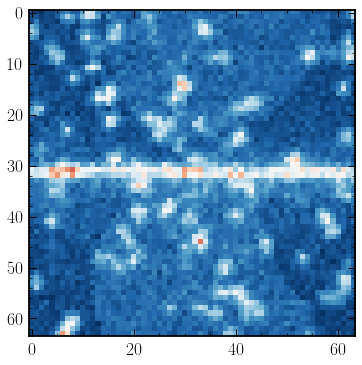

In [224]:
from celluloid import Camera

n_interp = 100

weights_ary = np.linspace(0, 1, n_interp)

fig = plt.figure(figsize=(6,6))

camera = Camera(fig)

for i in range(n_interp):
    
    x_dec = model.flow(z_interp(z[0], z[1], weight=weights_ary[i]).unsqueeze(0), reverse=True)[0]
    
    plt.imshow(x_dec[0,0].detach().numpy(), cmap=cmap, vmin=0, vmax=vrange)
    
    camera.snap()


In [225]:
animation = camera.animate()

In [226]:
from IPython.display import HTML
HTML(animation.to_html5_video())

In [227]:
animation.save('latent_interp.gif', fps=15)

## Regression network

In [228]:
from models.resnet import ResNetEstimator

In [229]:
class ResNetRegressor(pl.LightningModule):
    def __init__(self, n_out=3):
        super().__init__()
        
        self.save_hyperparameters()
        
        self.resnet = ResNetEstimator(cfg=18, n_out=n_out, log_input=False)
        self.loss = nn.MSELoss()
        
    def forward(self, x):
        x = self.resnet(x)
        return x
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=3e-4, weight_decay=1e-5)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)     
        loss = self.loss(y, out)
        self.log('train_loss', loss.mean(), on_epoch=True)
                
        return loss.mean()
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        out = self(x)     
        loss = self.loss(y, out)
        self.log('val_loss', loss.mean(), on_epoch=True)
        return loss.mean()

In [234]:
val_fraction = 0.1
n_samples_val = int(val_fraction * len(x))

y = torch.Tensor(np.array([mu_iso, mu_ps_iso])).T

# Normalize inputs
y_std = y.std(axis=0)
y_mean = y.mean(axis=0)
y_z = (y - y_mean) / y_std

x_z = torch.Tensor(x)
x_mean = x.mean()
x_std = x.std()
x_z = (x - x_mean) / x_std

dataset = TensorDataset(x_z.squeeze(), y_z)

dataset_train, dataset_val = random_split(dataset, [len(x) - n_samples_val, n_samples_val])
train_loader = DataLoader(dataset_train, batch_size=64, num_workers=8, shuffle=True)
val_loader = DataLoader(dataset_val, batch_size=64, num_workers=8, shuffle=False)

In [235]:
model_regressor = ResNetRegressor(n_out=2)

In [236]:
checkpoint_callback = ModelCheckpoint(monitor="val_loss")
trainer = pl.Trainer(max_epochs=15, gpus=1, gradient_clip_val=0.2, callbacks=[checkpoint_callback])
trainer.fit(model=model_regressor, train_dataloaders=train_loader, val_dataloaders=val_loader)
model_regressor.load_from_checkpoint(checkpoint_callback.best_model_path, n_out=2);  

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Set SLURM handle signals.

  | Name   | Type            | Params
-------------------------------------------
0 | resnet | ResNetEstimator | 12.2 M
1 | loss   | MSELoss         | 0     
-------------------------------------------
12.2 M    Trainable params
0         Non-trainable params
12.2 M    Total params
48.900    Total estimated model params size (MB)


Validation sanity check: 0it [00:00, ?it/s]

Training: -1it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

...

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

Validating: 0it [00:00, ?it/s]

In [764]:
model_regressor.eval();

In [765]:
y_pred = model_regressor((x[:20].squeeze() - x_mean) / x_std)

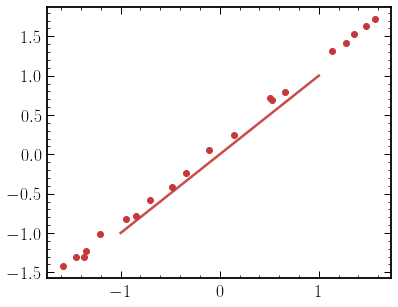

In [766]:
plt.scatter(y_z.detach().numpy()[:20, 0], y_pred.detach().numpy()[:, 0])
plt.plot([-1,1],[-1,1])

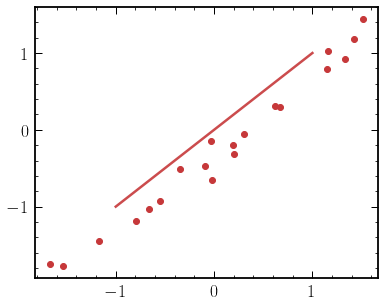

In [767]:
plt.scatter(y_z.detach().numpy()[:20, 1], y_pred.detach().numpy()[:, 1])
plt.plot([-1,1],[-1,1])

## Flow-to-regressor pipeline

In [847]:
x0 = x[0].unsqueeze(0)
z0, _ = model.flow(x0)

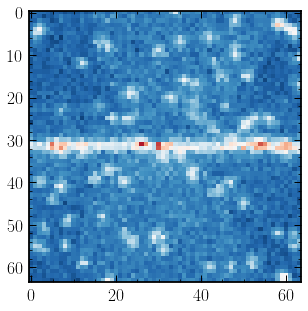

In [848]:
plt.imshow(x0[0,0].detach().numpy(), cmap=cmap, vmin=0, vmax=vrange)

In [853]:
model_regressor.resnet((x0[0] - x_mean) / x_std)

tensor([[ 0.7944, -0.6485]], grad_fn=<AddmmBackward0>)

In [854]:
model_regressor.resnet((x0[0] - x_mean) / x_std) * y_std + y_mean

tensor([[14.8800, 50.7845]], grad_fn=<AddBackward0>)

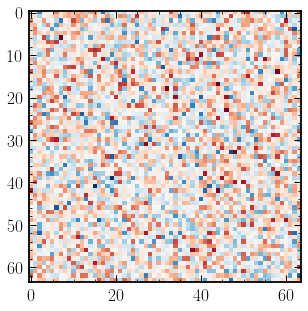

In [855]:
plt.imshow(z0[0,0].detach().numpy(), cmap=cmap)

In [856]:
model.eval()
model_regressor.eval();

In [864]:
# def objective(z):
#     return model_regressor.resnet(((model.flow(z, reverse=True)[0] - x_mean) / x_std)[0])[0, 0]

In [865]:
# def objective(z):
#     return model_regressor.resnet(z[0])[0, 0]

In [866]:
# def objective(z):
#     return model.flow(z, reverse=True)[0]

In [867]:
# z_detached = z0.detach()
# z_detached.requires_grad = True
# # z_detached.retain_grad()

In [868]:
# output = objective(z_detached)
# output

In [869]:
# from torch.autograd.functional import vjp, jvp, jacobian

# jacobian(objective, z_detached)

In [870]:
# from torch.autograd import grad

# grad(output, z_detached, retain_graph=True)

In [871]:
class DiffeomorphicConfounder(torch.nn.Module):
    def __init__(self, z0):
        """
        In the constructor we instantiate four parameters and assign them as
        member parameters.
        """
        super().__init__()
        self.z = torch.nn.Parameter(z0)

    def forward(self, param_idx=0):
        """
        In the forward function we accept a Tensor of input data and we must return
        a Tensor of output data. We can use Modules defined in the constructor as
        well as arbitrary operators on Tensors.
        """
#         return model_regressor.resnet(((model.flow(self.z.unsqueeze(0).unsqueeze(0), reverse=True)[0] - x_mean) / x_std)[0])[0, param_idx]
        return torch.diff(model_regressor.resnet(((model.flow(self.z.unsqueeze(0).unsqueeze(0), reverse=True)[0] - x_mean) / x_std)[0])[0, :])

In [876]:
dc = DiffeomorphicConfounder(z0[0,0])

optimizer = torch.optim.SGD(dc.parameters(), lr=1e-2)

for t in range(50):

    y_pred = - dc(1)
    print(y_pred)
    optimizer.zero_grad()
    y_pred.backward()
    optimizer.step()

tensor([-0.4110], grad_fn=<NegBackward0>)
tensor([-0.4339], grad_fn=<NegBackward0>)
tensor([-0.4564], grad_fn=<NegBackward0>)
tensor([-0.4798], grad_fn=<NegBackward0>)
tensor([-0.5031], grad_fn=<NegBackward0>)
tensor([-0.5249], grad_fn=<NegBackward0>)
tensor([-0.5471], grad_fn=<NegBackward0>)
tensor([-0.5670], grad_fn=<NegBackward0>)
tensor([-0.5867], grad_fn=<NegBackward0>)
tensor([-0.6048], grad_fn=<NegBackward0>)
tensor([-0.6239], grad_fn=<NegBackward0>)
tensor([-0.6416], grad_fn=<NegBackward0>)
tensor([-0.6602], grad_fn=<NegBackward0>)
tensor([-0.6799], grad_fn=<NegBackward0>)
tensor([-0.7004], grad_fn=<NegBackward0>)
tensor([-0.7288], grad_fn=<NegBackward0>)
tensor([-0.7547], grad_fn=<NegBackward0>)
tensor([-0.7787], grad_fn=<NegBackward0>)
tensor([-0.7992], grad_fn=<NegBackward0>)
tensor([-0.8197], grad_fn=<NegBackward0>)
tensor([-0.8400], grad_fn=<NegBackward0>)
tensor([-0.8705], grad_fn=<NegBackward0>)
tensor([-0.9002], grad_fn=<NegBackward0>)
tensor([-0.9202], grad_fn=<NegBack

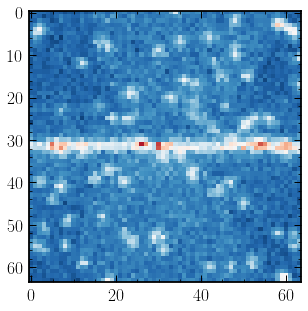

In [877]:
plt.imshow(x0[0,0].detach().numpy(), cmap=cmap, vmin=0, vmax=vrange)

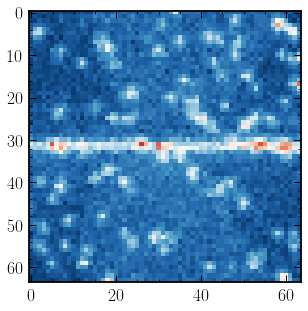

In [878]:
x_cf = model.flow(dc.z.unsqueeze(0).unsqueeze(0), reverse=True)[0][0,0]
x_cf = torch.floor(x_cf).clamp(min=0, max=model.flow.dequantization.quants-1).to(torch.int32).detach().numpy()

plt.imshow(x_cf, cmap=cmap, vmin=0, vmax=vrange)

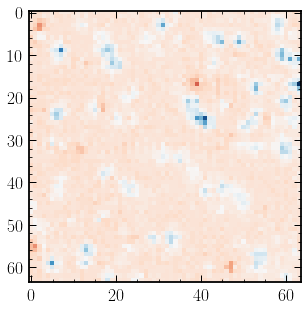

In [883]:
plt.imshow(x0[0,0].detach().numpy() - x_cf, cmap=cmap, vmin=-vrange / 3, vmax=vrange / 3)

In [880]:
x0[0,0].shape

torch.Size([64, 64])

In [881]:
model_regressor.resnet((x0[0] - x_mean) / x_std)

tensor([[ 0.7944, -0.6485]], grad_fn=<AddmmBackward0>)

In [882]:
model_regressor.resnet((torch.Tensor(x_cf).unsqueeze(0) - x_mean) / x_std)

tensor([[-0.4110,  0.9412]], grad_fn=<AddmmBackward0>)